In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal

In [3]:
file_path = "ES2008a.Mix-Headset.wav"
y, sr = librosa.load(file_path, sr=None)

duration_seconds = len(y) / sr
duration_minutes = duration_seconds / 60

print("Sample Rate:", sr)
print("Duration (minutes):", duration_minutes)

Sample Rate: 16000
Duration (minutes): 17.389333333333333


Hish-pass filter

In [4]:
nyquist = sr / 2
normal_cutoff = 80 / nyquist

b, a = signal.butter(4, normal_cutoff, btype='high', analog=False)
filtered = signal.filtfilt(b, a, y)

In [5]:
filtered,y

(array([ 1.25893411e-04,  1.31767729e-04,  4.61986181e-05, ...,
         1.64860784e-04,  7.21470086e-05, -2.19192857e-05]),
 array([ 0.0000000e+00,  0.0000000e+00, -9.1552734e-05, ...,
         2.7465820e-04,  2.1362305e-04,  1.5258789e-04], dtype=float32))

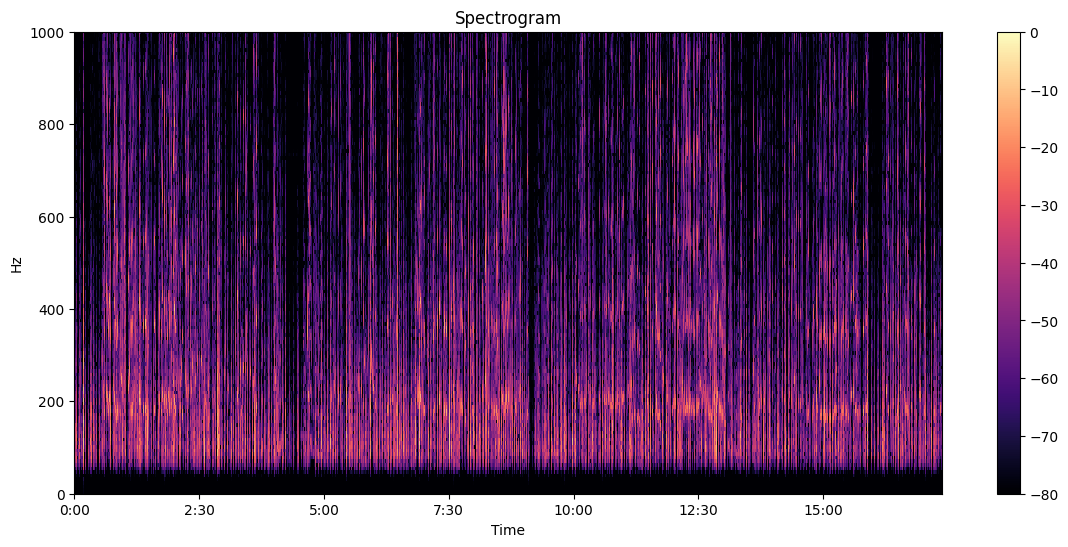

In [6]:
D = librosa.stft(filtered)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)


plt.figure(figsize=(14,6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")
plt.ylim(0, 1000)
plt.show()

As you can see we have removed the below 80hz noise this is a fixed bountry we have taken in later state we can still finetune this too

In [9]:
import noisereduce as nr

noise_sample = filtered[0:sr*5]

reduced_noise = nr.reduce_noise(
    y=filtered,
    sr=sr,
    y_noise=noise_sample,
    prop_decrease=0.8
)

In [11]:
def normalize(audio):
    return audio / np.max(np.abs(audio))

enhanced_audio = normalize(reduced_noise)

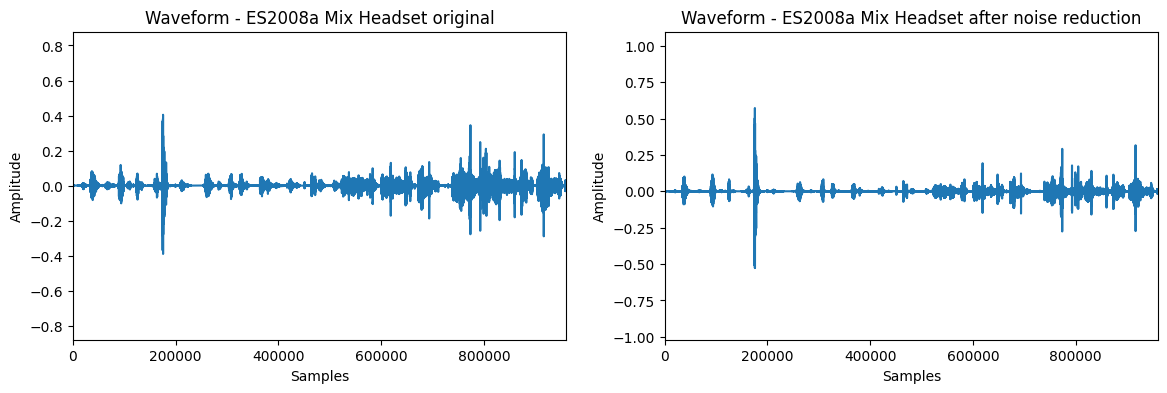

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(y)
plt.title("Waveform - ES2008a Mix Headset original")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.xlim(0, sr * 60)

plt.subplot(1,2,2)
plt.plot(enhanced_audio)
plt.title("Waveform - ES2008a Mix Headset after noise reduction")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.xlim(0, sr * 60)
plt.show()

We can see that the difference in amplititude in the how noise is removed by normalizing the noise value

In [18]:
import soundfile as sf

sf.write("enhanced_ES2008a.wav", enhanced_audio, sr)

In [19]:
signal_power = np.mean(enhanced_audio**2)

frame_length = 2048
hop_length = 512

energy = np.array([
    sum(abs(enhanced_audio[i:i+frame_length]**2))
    for i in range(0, len(enhanced_audio), hop_length)
])

sorted_energy = np.sort(energy)
noise_floor = np.mean(sorted_energy[:int(0.05*len(sorted_energy))])

snr_after = 10 * np.log10(signal_power / noise_floor)

print("SNR Before:", 6.82)
print("SNR After:", snr_after)

SNR Before: 6.82
SNR After: 16.996686036594063


We can se a drastic imporvement in the SNR 20 db is very good still we managed to improve it from  6 to 16 db thats great

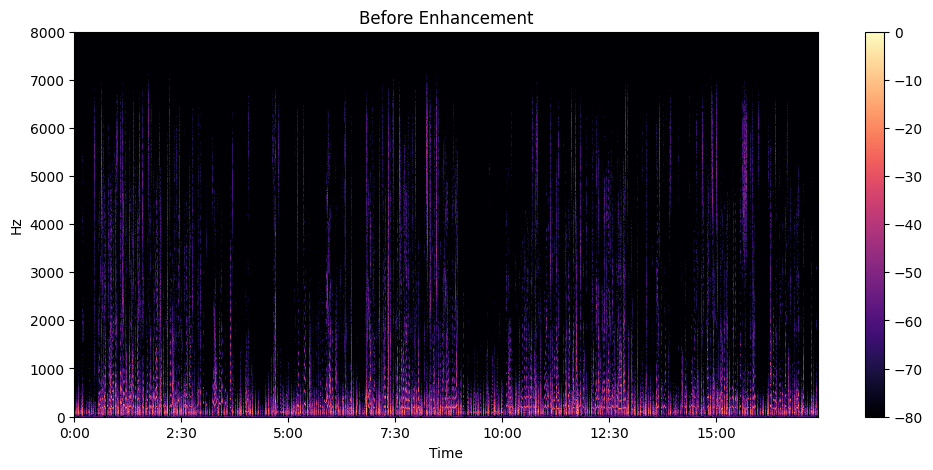

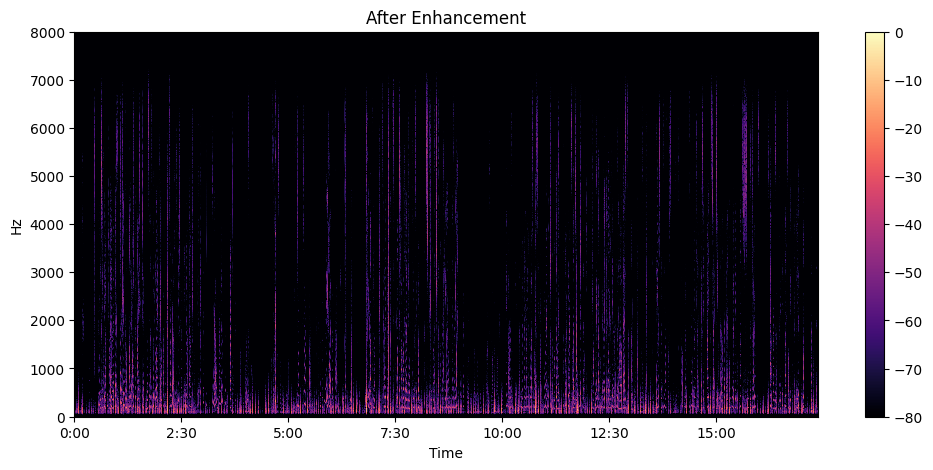

In [20]:
D_before = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
D_after = librosa.amplitude_to_db(np.abs(librosa.stft(enhanced_audio)), ref=np.max)

plt.figure(figsize=(12,5))
librosa.display.specshow(D_before, sr=sr, x_axis='time', y_axis='hz')
plt.title("Before Enhancement")
plt.colorbar()
plt.show()

plt.figure(figsize=(12,5))
librosa.display.specshow(D_after, sr=sr, x_axis='time', y_axis='hz')
plt.title("After Enhancement")
plt.colorbar()
plt.show()

As we can see the frequency graph the noise frequency is being normalized and taken care with 2 filtering method by using some other advanced method we can still make it better.